
# Optimistic Initial Values + ε-Greedy (Chapter 2 Demo)

This notebook compares four settings on the 10-armed testbed:

1. **Greedy, Q=0** (neutral initialization)  
2. **Greedy, Q=5** (optimistic initial values)  
3. **ε=0.1, Q=0** (ε-greedy)  
4. **ε=0.1, Q=5** (ε-greedy + optimistic)

We average over **200 runs** and **600 steps** here for speed.  
Increase `n_runs` (e.g., 1000–2000) locally for smoother curves.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

n_actions = 10
n_steps = 600
n_runs = 200
epsilons = [0.0, 0.1]
inits = [0.0, 5.0]


In [2]:

def choose_action(Q, epsilon, rng):
    if rng.random() < epsilon:
        return rng.integers(len(Q))
    m = np.max(Q)
    idx = np.flatnonzero(np.isclose(Q, m))
    return rng.choice(idx)

def simulate(initial_q=0.0, epsilon=0.0, n_actions=10, n_steps=1000, n_runs=200, seed=0):
    rng = np.random.default_rng(seed)
    avg_rewards = np.zeros(n_steps)
    opt_counts = np.zeros(n_steps)

    for r in range(n_runs):
        q_true = rng.normal(0.0, 1.0, size=n_actions)
        optimal = int(np.argmax(q_true))

        Q = np.ones(n_actions) * initial_q
        N = np.zeros(n_actions, dtype=int)

        for t in range(n_steps):
            a = choose_action(Q, epsilon, rng)
            reward = rng.normal(q_true[a], 1.0)

            N[a] += 1
            Q[a] += (reward - Q[a]) / N[a]

            avg_rewards[t] += reward
            if a == optimal:
                opt_counts[t] += 1

    avg_rewards /= n_runs
    opt_pct = opt_counts / n_runs * 100.0
    return avg_rewards, opt_pct


In [3]:

results = {}
for eps in epsilons:
    for init in inits:
        key = f"eps={eps}, Q0={init}"
        avg_r, opt_p = simulate(initial_q=init, epsilon=eps, n_actions=n_actions, n_steps=n_steps, n_runs=n_runs, seed=123)
        results[key] = (avg_r, opt_p)


## Average Reward

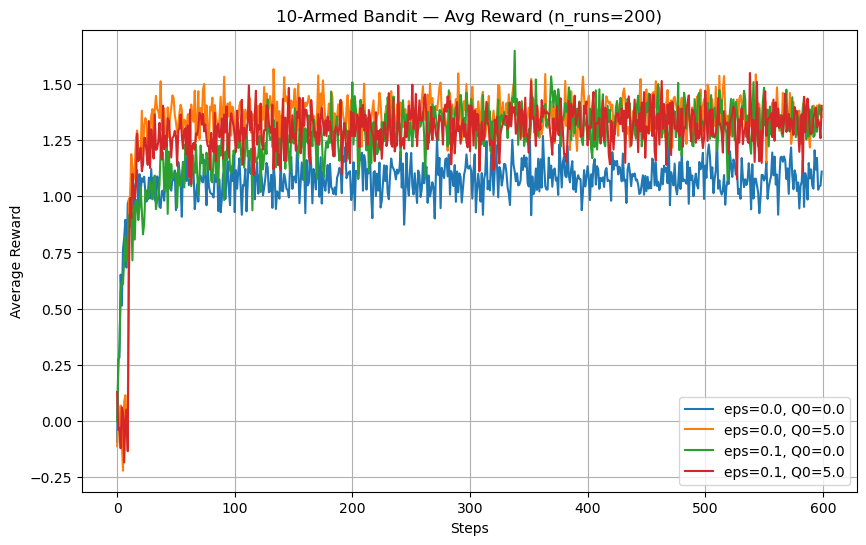

In [4]:

plt.figure(figsize=(10,6))
for key, (avg_r, _) in results.items():
    plt.plot(avg_r, label=key)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title(f"10-Armed Bandit — Avg Reward (n_runs={n_runs})")
plt.grid(True)
plt.legend()
plt.show()


## Percentage of Optimal Action

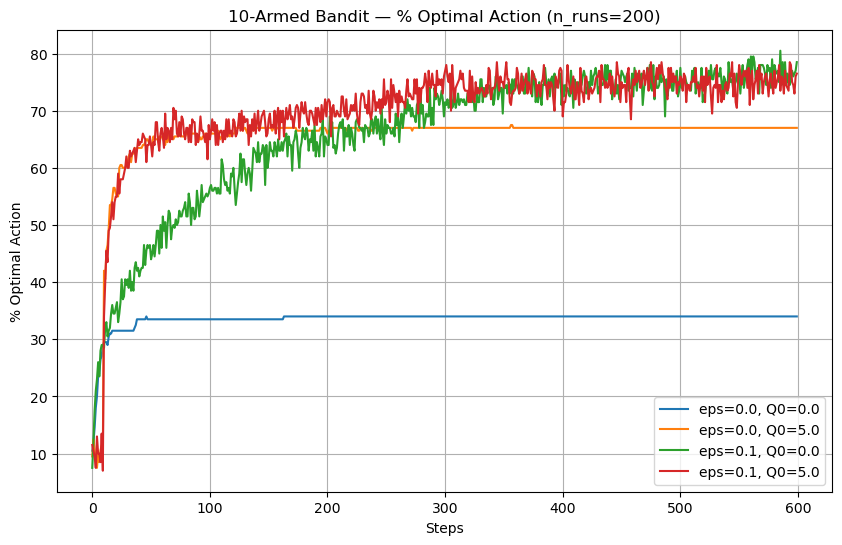

In [5]:

plt.figure(figsize=(10,6))
for key, (_, opt_p) in results.items():
    plt.plot(opt_p, label=key)
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title(f"10-Armed Bandit — % Optimal Action (n_runs={n_runs})")
plt.grid(True)
plt.legend()
plt.show()



### Notes

- **Optimistic initial values (Q=5)** spark early exploration even with greedy selection.
- **ε-greedy (ε=0.1)** adds continued random exploration; combining with optimism usually speeds early learning.
- For nonstationary problems, prefer constant step-size updates instead of sample averages.
